# HR Analytics – Predicting Job Change of Data Scientists

## Project Overview

Employee retention is a major challenge for organisations, particularly in highly competitive fields such as data science. Companies invest significant resources in recruiting and training employees, and losing skilled professionals can result in increased recruitment costs, loss of productivity, and disruption to organisational performance.

This project analyses HR recruitment data to understand the factors that influence whether a candidate will change jobs after completing training. Using exploratory data analysis and machine learning techniques, the project aims to identify the key drivers behind employee job change and build predictive models that estimate the probability of a candidate leaving for another opportunity.

The insights from this analysis can help organisations improve hiring strategies, training investments, and workforce planning decisions.

---

## Problem Statement

In competitive industries, organisations face high employee turnover rates. Predicting which candidates are more likely to change jobs can help HR departments develop better retention strategies and make more informed hiring decisions.

This project aims to answer the following questions:

- Which factors influence whether a candidate will change jobs?
- How do experience, education, and company characteristics affect job mobility?
- Can machine learning models predict the likelihood of a candidate changing jobs?

---

## Dataset

The dataset contains information about data science candidates who participated in training programs. It includes demographic information, education level, work experience, company characteristics, and training history.

### Features

- **enrollee_id** : Unique ID for candidate
- **city**: City code
- **city_ development _index** : Developement index of the city (scaled)
- **gender**: Gender of candidate
- **relevent_experience**: Relevant experience of candidate
- **enrolled_university**: Type of University course enrolled if any
- **education_level**: Education level of candidate
- **major_discipline** :Education major discipline of candidate
- **experience**: Candidate total experience in years
- **company_size**: No of employees in current employer's company
- **company_type** : Type of current employer
- **lastnewjob**: Difference in years between previous job and current job
- **training_hours**: training hours completed 

### Target Variable

- **target** – Indicates whether the candidate changed jobs after training  
  - `0` – Did not change job  
  - `1` – Changed job

---

## Project Workflow

### 1. Data Loading and Inspection

The dataset was imported and inspected to understand its structure, variable types, and missing values.

---

### 2. Exploratory Data Analysis (EDA)

Exploratory data analysis was conducted to identify patterns and relationships between variables.

Key analyses included:

- Distribution of candidate experience levels
- Relationship between city development index and job mobility
- Impact of education level on job change
- Relationship between company size and candidate turnover

Visualisations were used to highlight trends and support insights.

---

### 3. Data Cleaning

Data preprocessing steps included:

- Handling missing values
- Converting categorical variables
- Preparing data for machine learning models

These steps ensured that the dataset was clean and suitable for analysis.

---

### 4. Feature Engineering

Categorical variables were encoded and numerical variables were prepared for machine learning algorithms.

Feature preparation helped improve model performance and ensured the dataset could be effectively used for prediction tasks.

---

### 5. Machine Learning Models

Two machine learning models were trained to predict whether a candidate would change jobs:

#### Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

#### Gradient Boosting Classifier

Gradient Boosting builds models sequentially, where each new model corrects the errors of previous models. It is often highly effective for classification problems.

---

### 6. Model Evaluation

The models were evaluated using standard classification metrics, including:

- Precision_score
- Confusion Matrix
- F1_score

- Feature Importance

These metrics help assess how well the models distinguish between candidates who changed jobs and those who stayed.

---

## Key Insights

- The analysis revealed several important factors influencing job change:
  
**Experience Level**
- Candidates with fewer years of experience are more likely to change jobs. Early-career professionals often seek better opportunities to advance their careers.

**City Development Index**
- Candidates located in highly developed cities tend to have more job opportunities, leading to higher job mobility.

**Company Size**

- Employees working in smaller companies appear more likely to change jobs compared to those in larger organisations.

**Education Level**

- Higher education levels can influence career mobility and opportunities for job change.

---

## Business Implications

The findings from this analysis can help organisations:

- Identify candidates with higher risk of job change
- Improve recruitment strategies
- Develop targeted retention programs
- Optimise training investments

Using predictive analytics allows HR teams to make more informed workforce decisions.

---

## Limitations

While the models provide useful predictions, several limitations exist:

- Some variables contain missing data
- The dataset may not fully represent all industries or regions
- Additional external factors influencing job mobility are not included

Future work could incorporate additional datasets and advanced modelling techniques.

---

## Future Improvements

Potential extensions for this project include:

- Testing additional machine learning models
- Using feature selection techniques
- Building an interactive HR analytics dashboard
- Deploying the model as a predictive HR tool

---

## Conclusion

This project demonstrates how data analytics and machine learning can be applied to HR data to understand employee behaviour and predict job mobility. By analysing candidate characteristics and training data, the models provide insights into the key factors that influence job change decisions.

These insights can support organisations in improving recruitment strategies and developing more effective employee retention policies.

---


In [1]:
# Import the data visualation and manipulation tools 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
# Models from scikit-Learn 
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
# resample by adding samples to minority class using SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

# Model Evaluations
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix,RocCurveDisplay
from sklearn.metrics import precision_score, recall_score , f1_score


In [3]:
%matplotlib inline

## Load Data 

In [4]:
df = pd.read_csv('aug_train.csv')

In [5]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## Data Explolatory 

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 3.

In [7]:
df.isnull().sum() # check missing data 

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

<Axes: >

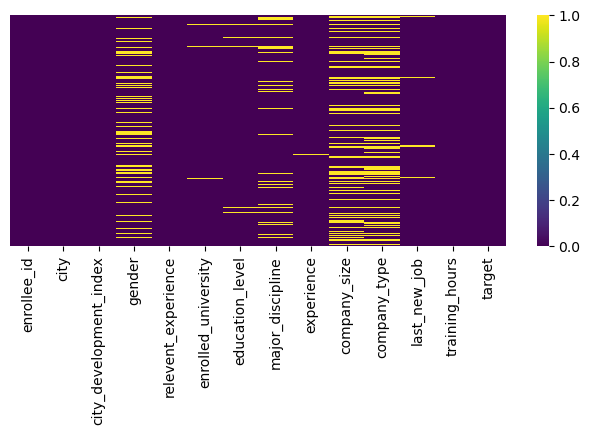

In [8]:
plt.figure(figsize=(8,3))
sns.heatmap(df.isnull(),yticklabels=False,cmap='viridis') 

In [9]:
df.isnull().mean() # percentage of missing data 

enrollee_id               0.000000
city                      0.000000
city_development_index    0.000000
gender                    0.235306
relevent_experience       0.000000
enrolled_university       0.020148
education_level           0.024011
major_discipline          0.146832
experience                0.003393
company_size              0.309949
company_type              0.320493
last_new_job              0.022080
training_hours            0.000000
target                    0.000000
dtype: float64

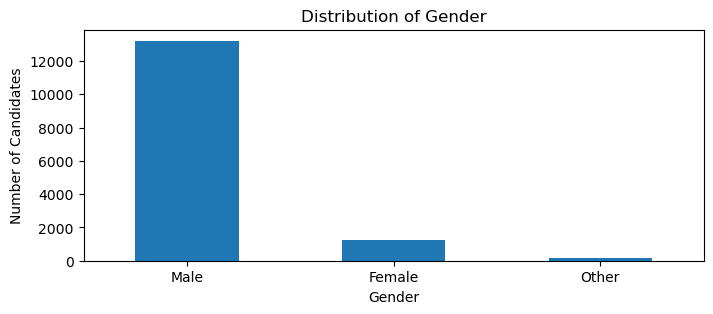

In [10]:
plt.figure(figsize=(8,3))
df['gender'].value_counts().plot.bar()
plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=0)
plt.show()

The chart shows a highly imbalanced gender distribution, with male candidates overwhelmingly dominating (around 13,000), female candidates forming a much smaller portion (1,000–1,500), and the “other” category being nearly negligible. This indicates a strong skew toward males in the dataset, which could introduce bias in analysis or machine learning models and may require techniques like resampling or class weighting to ensure fair outcomes.


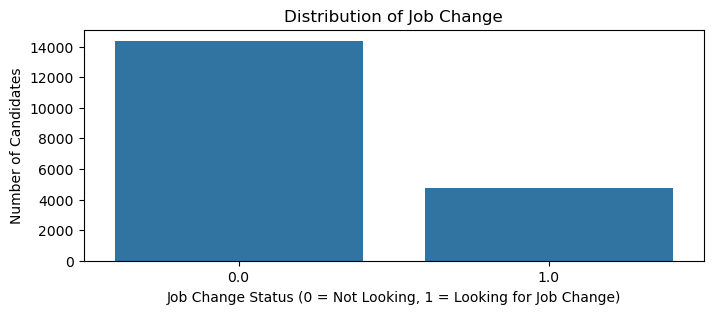

In [11]:
plt.figure(figsize=(8,3))
sns.countplot(x='target', data=df)
plt.title("Distribution of Job Change")
plt.xlabel('Job Change Status (0 = Not Looking, 1 = Looking for Job Change)')
plt.ylabel("Number of Candidates")
plt.show()

The chart shows the distribution of job changes, where 0=no change and 1=changed jobs.
A significantly larger portion of individuals (around 14,000) did not change jobs 
compared to those who did (around 4500). This indicates a clear class imbalance, with most employees remaining in their current roles.

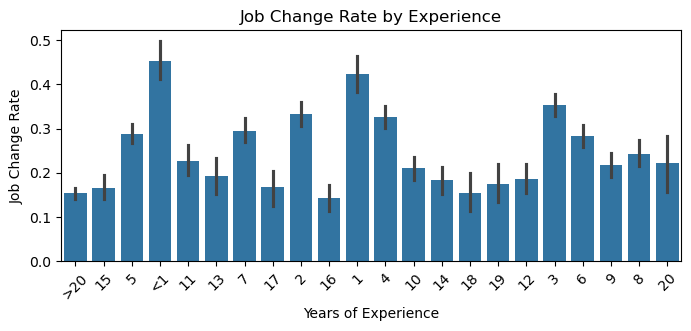

In [15]:
plt.figure(figsize=(8,3))
sns.barplot(x='experience', y='target', data=df)
plt.xticks(rotation=45)
plt.title("Job Change Rate by Experience")
plt.xlabel('Years of Experience')
plt.ylabel('Job Change Rate')
plt.show()

The chart shows that job change rates vary noticeably by experience level, with the highest rates occurring among employees with very low experience (especially <1 year and around 1 year), suggesting early-career professionals are more likely to switch jobs. As experience increases, the job change rate generally declines and stabilizes at lower levels, indicating more experienced employees tend to stay longer in their roles. Overall, this reflects a clear trend where job mobility is highest at the beginning of careers and decreases with experience.


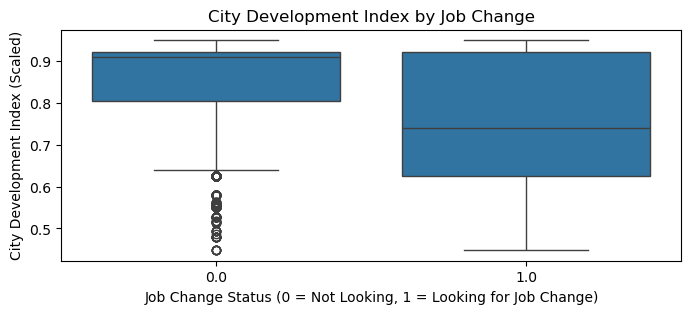

In [20]:
plt.figure(figsize=(8,3))
sns.boxplot(x='target', y='city_development_index', data=df)
plt.title("City Development Index by Job Change")
plt.xlabel('Job Change Status (0 = Not Looking, 1 = Looking for Job Change)')
plt.ylabel('City Development Index (Scaled)')
plt.show()

This analysis explores the relationship between the City Development Index (CDI) and job change behavior by comparing individuals who did not change jobs (target = 0) with those who did (target = 1). The boxplot shows a clear distinction between the two groups. Individuals who remained in their jobs tend to have a higher CDI, with values concentrated around 0.8–0.9, indicating they are mostly located in highly developed cities. In contrast, individuals who changed jobs have a lower median CDI (around 0.7) and a wider spread, suggesting they come from a broader range of cities, including less developed areas. Although a few individuals in lower-CDI cities did not change jobs (seen as outliers), the overall pattern is consistent.

Overall, the results indicate a negative relationship between city development and job change. People in less developed cities are more likely to change jobs, possibly in search of better opportunities, while those in highly developed cities tend to remain in their current roles, likely due to greater job stability and availability of opportunities locally. In conclusion, city development plays an important role in job mobility, with lower development linked to higher job movement and higher development associated with job stability.

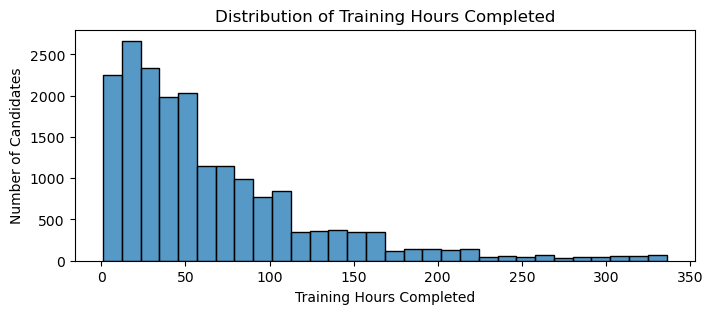

In [21]:
plt.figure(figsize=(8,3))
sns.histplot(df['training_hours'], bins=30)
plt.title("Distribution of Training Hours Completed")
plt.xlabel("Training Hours Completed")
plt.ylabel("Number of Candidates")
plt.show()

The histogram shows how training hours are spread across candidates, and it reveals a highly right-skewed distribution.

Most candidates cluster in the lower range of training hours—roughly between 0 and 60 hours, where the tallest bars appear. This indicates that a large proportion of individuals have relatively limited training. As training hours increase beyond this range, the frequency of candidates steadily declines, forming a long tail that stretches out to around 300+ hours. This tail suggests that only a small number of candidates invest significantly more time in training.

The shape of the distribution implies high variability in training exposure. While the majority have minimal to moderate training, a few outliers with very high hours pull the distribution to the right. Because of this skewness, the mean training hours is likely higher than the median, and the median would better represent a typical candidate.

From an interpretation standpoint, this uneven distribution could have important implications: candidates with fewer training hours may be less prepared, while those with extensive training could have a competitive advantage. Overall, the data suggests that training is not uniformly distributed, which may lead to disparities in skill levels and job readiness across the candidate pool.

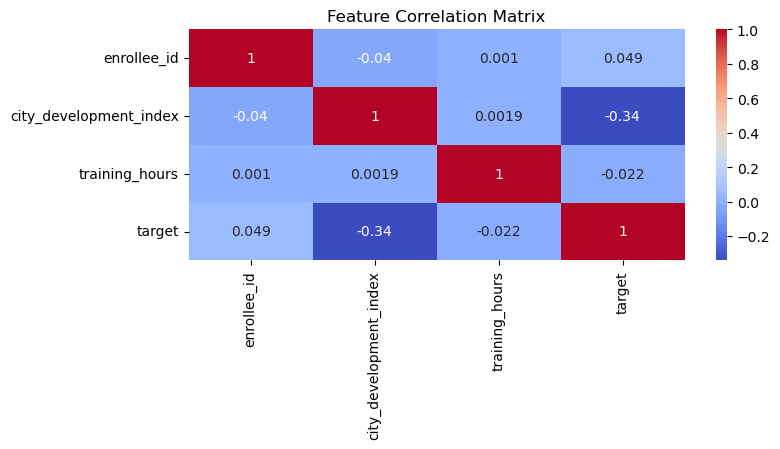

In [22]:
plt.figure(figsize=(8,3))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

The heatmap shows the linear relationships between your features (enrollee_id, city_development_index, training_hours) and the target. Most correlations are very close to zero, which means there are generally weak linear relationships in the dataset.

The most important insight comes from city_development_index, which has a moderate negative correlation (-0.34) with the target. This suggests that as the development level of a city increases, the likelihood of the target outcome decreases. In practical terms, this is the only feature showing a meaningful linear relationship with the target and is likely to be an important predictor.

On the other hand, training_hours has a correlation of -0.022 with the target, which is essentially zero. This indicates that training hours alone do not have a strong direct linear impact on the target variable. However, this does not necessarily mean the feature is useless—it may still contribute through non-linear relationships or interactions with other variables.

Additionally, correlations between independent features are extremely low (close to 0), meaning there is no multicollinearity issue. This is beneficial because the features are not redundant and won’t distort model behavior.

Overall, the dataset shows limited linear signal, with only one moderately useful feature. 

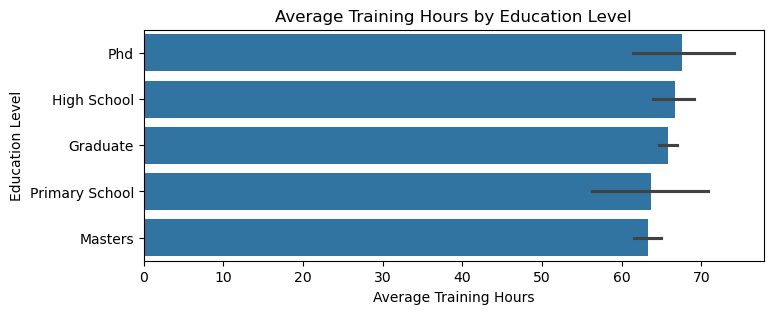

In [23]:
plt.figure(figsize=(8,3))
order = df.groupby(["education_level"])["training_hours"].mean().sort_values(ascending=False).index
sns.barplot(x='training_hours',y='education_level',data=df,order=order)
plt.title("Average Training Hours by Education Level")
plt.xlabel('Average Training Hours')
plt.ylabel('Education Level')
plt.show()

This visualization shows the average training hours across different education levels, sorted from highest to lowest. The horizontal bar chart makes it easy to compare how much time individuals with different educational backgrounds spend in training.

From the chart, individuals with a PhD have the highest average training hours, slightly above 70 hours. This suggests that highly educated individuals tend to engage more in continuous learning or professional development, possibly due to the demands of specialized or research-oriented roles.

Next come those with a High School education and Graduate degrees, both showing relatively similar training hours in the mid-to-high 60s. This indicates that even individuals without advanced degrees are still significantly involved in training, which may reflect organizational efforts to upskill employees regardless of their formal education level.

Those with Primary School education and Master’s degrees have slightly lower average training hours, around the low 60s. The relatively lower value for Primary School is understandable, as such roles may require less formal training. However, the slightly lower training time for Master’s degree holders is interesting—it may imply that they already possess specialized knowledge, reducing the need for additional training, or that their roles demand less frequent training updates compared to PhD-level roles.

Overall, the differences across education levels are not extremely large, with all groups clustering roughly between 60 and 72 hours. This suggests that training is fairly evenly distributed across the organization, with only a mild tendency for higher education levels to correspond to slightly more training. It reflects a generally consistent investment in employee development across all educational backgrounds, rather than a sharply segmented approach.

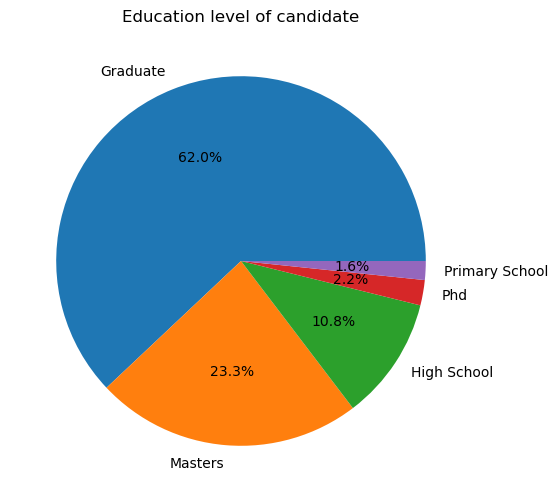

In [24]:
plt.figure(figsize=(10,6))
ax = df['education_level'].value_counts().plot(kind='pie',autopct='%1.1f%%')
ax.yaxis.set_visible(False)
plt.title('Education level of candidate');
plt.show();

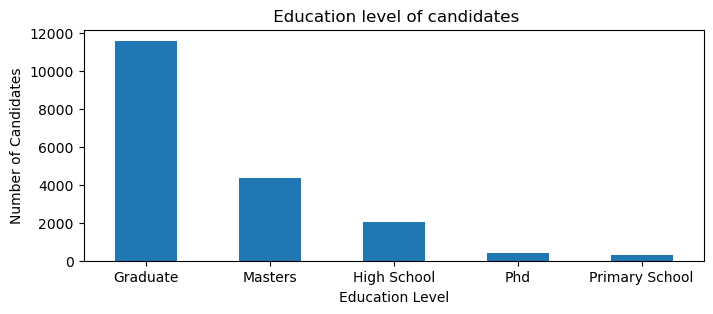

In [25]:
plt.figure(figsize=(8,3))
df['education_level'].value_counts().plot.bar() 
plt.xlabel('Education Level')
plt.ylabel('Number of Candidates')
plt.title(' Education level of candidates');
plt.xticks(rotation=0)
plt.show();


The organization has a highly educated workforce, with most candidates holding at least a graduate degree. Graduates form the majority, followed by a strong proportion of master’s degree holders, indicating a solid base of skilled and knowledgeable employees.

Lower education levels, such as high school and primary school, make up a smaller share, while PhD holders are very few. This suggests the company focuses more on practical skills and operational efficiency rather than research-intensive work.

Overall, the workforce structure is balanced and pyramid-shaped, emphasizing graduates and postgraduates as the key drivers of performance and growth

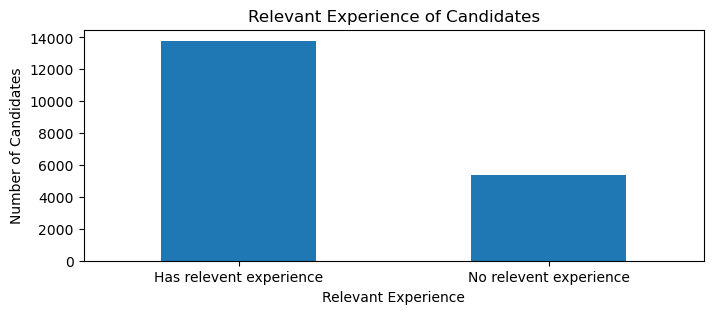

In [26]:
plt.figure(figsize=(8,3))
df['relevent_experience'].value_counts().plot.bar()
plt.xlabel('Relevant Experience')
plt.ylabel('Number of Candidates')
plt.title('Relevant Experience of Candidates')
plt.xticks(rotation=0)
plt.show()

The majority of Candidates possess relevant experience.

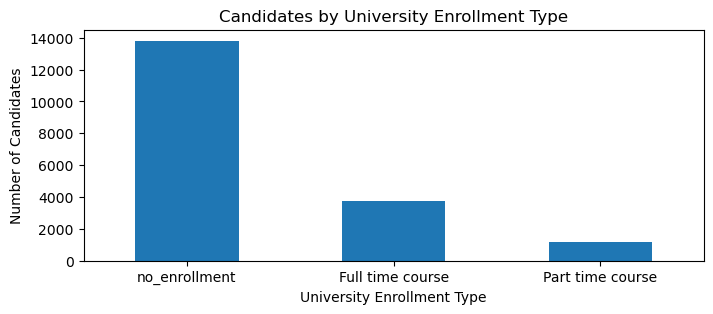

In [27]:
plt.figure(figsize=(8,3))
df['enrolled_university'].value_counts().plot.bar()
plt.xlabel('University Enrollment Type')
plt.ylabel('Number of Candidates')
plt.title('Candidates by University Enrollment Type')
plt.xticks(rotation=0)
plt.show()

The majority of Candidates fall under the no_enrollment category,whereas part_time course enrollment represents the smallest group.

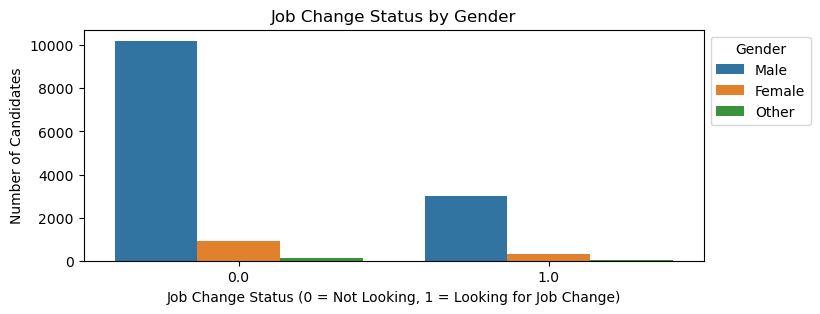

In [28]:
plt.figure(figsize=(8,3))
sns.countplot(x='target',data=df,hue='gender')
plt.xlabel('Job Change Status (0 = Not Looking, 1 = Looking for Job Change)')
plt.ylabel('Number of Candidates')
plt.legend(title='Gender',loc='upper left', bbox_to_anchor=(1, 1));
plt.title('Job Change Status by Gender')
plt.show()

- The dataset is highly imbalanced, with significantly more individuals not looking for a job change (0) than those who are (1).
- There is a strong gender imbalance, as males make up the vast majority of the dataset, while females and the “Other” category are underrepresented.
- Across all gender groups, the same pattern holds: most individuals are not actively seeking a job change, indicating a consistent trend.
- There is no clear visual evidence of major differences in job change behavior between genders, although this may be influenced by the unequal representation.
- The low counts for female and “Other” categories limit the reliability of comparisons and may introduce bias in analysis.

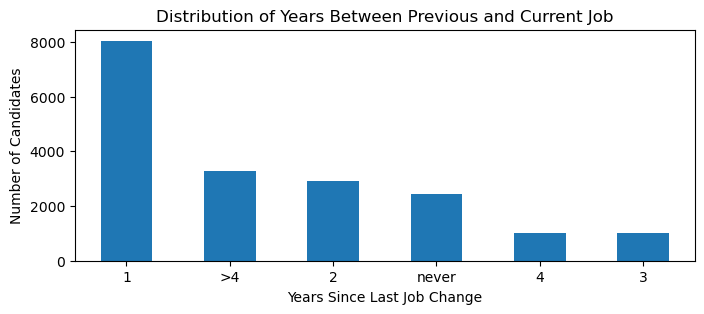

In [29]:
plt.figure(figsize=(8,3))
df['last_new_job'].value_counts().plot.bar();
plt.xlabel('Years Since Last Job Change')
plt.ylabel('Number of Candidates')
plt.title('Distribution of Years Between Previous and Current Job')
plt.xticks(rotation=0)
plt.show()

The last_new_job variable, which represents the number of years between a person’s previous job and their current one, shows a clear pattern in job mobility: the majority of individuals changed jobs after just 1 year, indicating that short job cycles are very common and suggesting a highly dynamic workforce, likely driven by early-career exploration or frequent opportunity switching; beyond this, there is a noticeable drop, with smaller but still significant groups in the 2-year and >4-year categories, implying that while many people switch quickly, a considerable portion either stabilizes and stays longer or takes more time before transitioning; the “never” category also has a meaningful count, indicating individuals who have not changed jobs at all, possibly fresh entrants or those in their first roles; meanwhile, the 3- and 4-year categories have relatively low counts, suggesting that mid-range job changes are less typical compared to very early or much later switches; overall, the distribution is skewed toward shorter job intervals with a dominant peak at 1 year, combined with a secondary pattern of long-term stability, highlighting a workforce split between frequent movers and longer-tenured individuals.

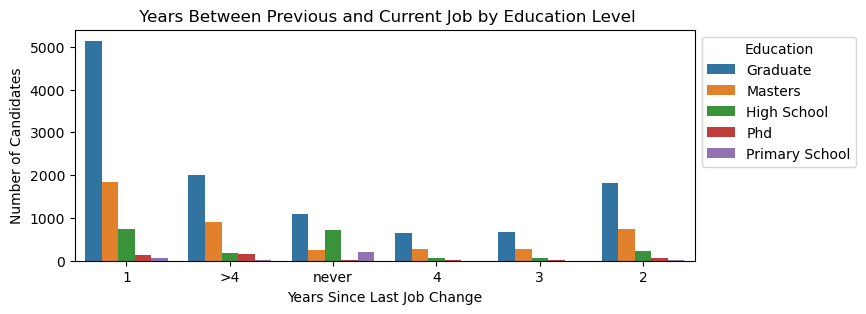

In [30]:
plt.figure(figsize=(8,3))
sns.countplot(x='last_new_job',data=df,hue='education_level');
plt.xlabel('Years Since Last Job Change')
plt.ylabel('Number of Candidates')
plt.title(' Years Between Previous and Current Job by Education Level')
plt.legend(title='Education',loc='upper left', bbox_to_anchor=(1, 1));
plt.show()

The analysis of the last_new_job variable shows that most individuals change jobs within one year, with graduates contributing the largest share. This indicates high early-career mobility, especially among those with higher education, likely driven by better opportunities and career exploration. As the gap between job changes increases, the number of individuals declines, though some still switch after two to four years, reflecting a mix of frequent movers and more stable employees.

Education level significantly influences these patterns. Graduates and master’s degree holders exhibit higher job mobility, while individuals with lower education levels are more likely to have never changed jobs or show lower movement overall. Smaller groups, such as PhD holders, have limited representation, making trends less clear.

Overall, the findings suggest that higher education is associated with greater job mobility and a higher risk of early attrition. This highlights the need for organizations to focus on retention strategies, particularly during the first one to two years of employment.

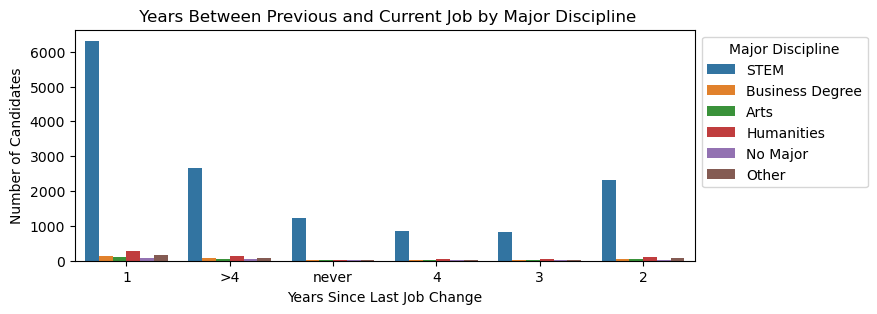

In [31]:
plt.figure(figsize=(8,3))
sns.countplot(x='last_new_job',data=df,hue='major_discipline');
plt.xlabel('Years Since Last Job Change')
plt.ylabel('Number of Candidates')
plt.title(' Years Between Previous and Current Job by Major Discipline')
plt.legend(title='Major Discipline',loc='upper left', bbox_to_anchor=(1, 1));
plt.show();

The distribution of the last_new_job variable shows that most individuals change jobs relatively quickly, with the highest concentration at 1 year, followed by smaller groups at 2 years and more than 4 years, while longer or no job changes are much less common. This indicates that early job mobility is the dominant trend, particularly within the first one to two years of employment. Across disciplines, STEM graduates strongly dominate the sample and exhibit the highest mobility, frequently switching jobs within short timeframes, while other fields such as business, arts, and humanities follow a similar but less pronounced pattern due to smaller representation. Overall, the results suggest a workforce characterized by frequent early-career job changes and limited long-term retention, highlighting the importance for employers to focus on retaining employees during the initial years.

## Feature Engineering
### Fill missing values 


In [32]:
df_copy = df.copy()

In [33]:
# Check if there's any null non numeric values 
for label, content in df_copy.items():
    if not pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

gender
enrolled_university
education_level
major_discipline
experience
company_size
company_type
last_new_job


In [34]:
for label,content in df_copy.items():
    if not pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells us if the data was missing 
            df_copy[label+"_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with missing arbitrary
            df_copy[label] = content.fillna('Missing')




            

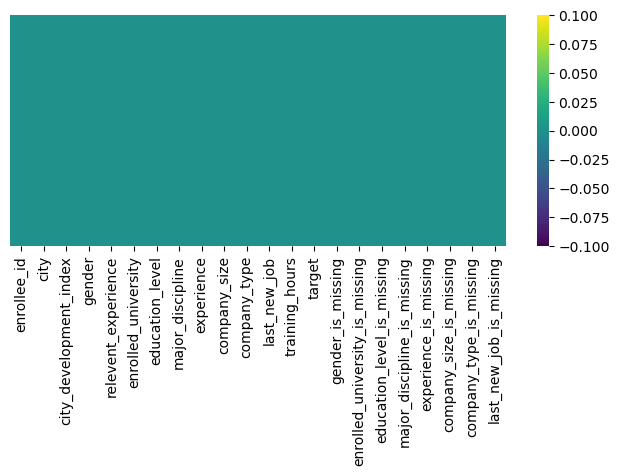

In [35]:
plt.figure(figsize=(8,3))
sns.heatmap(df_copy.isnull(),yticklabels=False,cmap='viridis'); # check if there are still missing values 

In [36]:
df_copy['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Missing               386
Name: count, dtype: int64

### Turning categorical data into dummy or indicator variables 

In [37]:
df_copy.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,training_hours,target,gender_is_missing,enrolled_university_is_missing,education_level_is_missing,major_discipline_is_missing,experience_is_missing,company_size_is_missing,company_type_is_missing,last_new_job_is_missing
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Missing,...,36,1.0,False,False,False,False,False,True,True,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,47,0.0,False,False,False,False,False,False,False,False
2,11561,city_21,0.624,Missing,No relevent experience,Full time course,Graduate,STEM,5,Missing,...,83,0.0,True,False,False,False,False,True,True,False
3,33241,city_115,0.789,Missing,No relevent experience,Missing,Graduate,Business Degree,<1,Missing,...,52,1.0,True,True,False,False,False,True,False,False
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,8,0.0,False,False,False,False,False,False,False,False


In [38]:
df_copy['last_new_job'].value_counts()

last_new_job
1          8040
>4         3290
2          2900
never      2452
4          1029
3          1024
Missing     423
Name: count, dtype: int64

In [39]:
gender = pd.get_dummies(df_copy['gender'],drop_first=True)
relevent_experience = pd.get_dummies(df_copy['relevent_experience'],drop_first=True)
enrolled_university = pd.get_dummies(df_copy['enrolled_university'],drop_first=True)
education_level = pd.get_dummies(df_copy['education_level'],drop_first=True)
major_discipline = pd.get_dummies(df_copy['major_discipline'],drop_first=True)
experience = pd.get_dummies(df_copy['experience'],drop_first=True)
company_size = pd.get_dummies(df_copy['company_size'],drop_first=True)
company_type = pd.get_dummies(df_copy['company_type'],drop_first=True)
last_new_job = pd.get_dummies(df_copy['last_new_job'],drop_first=True) 

In [40]:
final_df = pd.concat([df_copy,gender,relevent_experience,enrolled_university,education_level,major_discipline,
                      experience,company_size,company_type,last_new_job],axis=1)

In [41]:
final_df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,NGO,Other,Public Sector,Pvt Ltd,2,3,4,>4,Missing,never
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Missing,...,False,False,False,False,False,False,False,False,False,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,False,False,False,True,False,False,False,True,False,False
2,11561,city_21,0.624,Missing,No relevent experience,Full time course,Graduate,STEM,5,Missing,...,False,False,False,False,False,False,False,False,False,True
3,33241,city_115,0.789,Missing,No relevent experience,Missing,Graduate,Business Degree,<1,Missing,...,False,False,False,True,False,False,False,False,False,True
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,False,False,False,False,False,False,True,False,False,False


In [42]:
final_df.drop(['enrollee_id','city','gender',
               'relevent_experience','enrolled_university',
               'education_level','major_discipline','experience','company_size','company_type',
               'last_new_job'],axis=1,inplace=True)

In [43]:
final_df

,city_development_index,training_hours,target,gender_is_missing,enrolled_university_is_missing,education_level_is_missing,major_discipline_is_missing,experience_is_missing,company_size_is_missing,company_type_is_missing,...,NGO,Other,Public Sector,Pvt Ltd,2,3,4,>4,Missing,never
0,0.920,36,1.0,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,0.776,47,0.0,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,0.624,83,0.0,True,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,True
3,0.789,52,1.0,True,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
4,0.767,8,0.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,0.878,42,1.0,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
19154,0.920,52,1.0,False,False,False,False,False,True,True,...,False,False,False,False,False,False,True,False,False,False
19155,0.920,44,0.0,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
19156,0.802,97,0.0,False,False,False,True,False,False,False,...,False,False,False,True,True,False,False,False,False,False


## Dealing with Imbalanced Data 
### Combination of Over- and Under-sampling/ Hybrid Methods
There are two ready-to-use classes imbalanced-learn implements for combining over- and under-sampling methods are SMOTETomek and SMOTEENN.

In [44]:
X = final_df.drop('target',axis=1) # just the features 
y=final_df['target'] # target

In [45]:
# resample by adding samples to minority class using SMOTE
X_ =np.array(X)
resample = SMOTETomek(tomek=TomekLinks(sampling_strategy='majority'))
X_oversamp, Y_over_samp = resample.fit_resample(X_, y)

C:\Users\hi\anaconda5\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\hi\anaconda5\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\hi\anaconda5\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\hi\anaconda5\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  Fi

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_oversamp,
                                                    Y_over_samp,
                                                    test_size=0.3,
                                                    random_state = 42)

In [47]:
X_train.shape , X_test.shape

((20019, 70), (8580, 70))

## Modelling 

In [48]:
# Put models in a dictionary  
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(),'Gradient Boosting':GradientBoostingClassifier()}

# create a function to fit and score models 
def fit_and_score(models, X_train,X_test,y_train,y_test):

    # set random seed 
    np.random.seed(42)
    # Make a dictionary to keep model scores 
    model_scores = {}
    # Loop through models 
    for name, model in models.items():
        # Fit the model to the data 
        model.fit(X_train,y_train)
        # Evaluate the model and apppend its score to model_scores
        model_scores[name] = model.score(X_test,y_test)
    return model_scores

In [49]:
model_scores = fit_and_score(models=models, X_train=X_train,X_test=X_test,y_train=y_train,y_test=y_test)
model_scores

C:\Users\hi\anaconda5\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7437062937062937,
 'KNN': 0.706060606060606,
 'Random Forest': 0.8511655011655012,
 'Gradient Boosting': 0.8453379953379954}

## Hyperparameter tuning with RandomizedSearchCV


In [50]:
# Create a hyperparameter grid for RandomForestClassifier 
gr= {"n_estimators": np.arange(10, 8000, 50),
           "max_depth": [None, 3, 5, 10], 
           "min_samples_split": np.arange(2,20,2),
           "min_samples_leaf": np.arange(1, 20, 2)}


clf = RandomizedSearchCV(estimator=RandomForestClassifier(n_jobs=1),param_distributions=gr,
                         verbose=2,
                         cv=5,
                         n_iter=20
                        )
clf.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, min_samples_leaf=7, min_samples_split=16, n_estimators=3110; total time=  48.7s
[CV] END max_depth=10, min_samples_leaf=7, min_samples_split=16, n_estimators=3110; total time=  48.2s
[CV] END max_depth=10, min_samples_leaf=7, min_samples_split=16, n_estimators=3110; total time=  47.4s
[CV] END max_depth=10, min_samples_leaf=7, min_samples_split=16, n_estimators=3110; total time=  47.7s
[CV] END max_depth=10, min_samples_leaf=7, min_samples_split=16, n_estimators=3110; total time=  48.2s
[CV] END max_depth=10, min_samples_leaf=9, min_samples_split=14, n_estimators=4760; total time= 1.2min
[CV] END max_depth=10, min_samples_leaf=19, min_samples_split=6, n_estimators=4010; total time= 2.4min
[CV] END max_depth=10, min_samples_leaf=19, min_samples_split=6, n_estimators=4010; total time= 2.5min
[CV] END max_depth=10, min_samples_leaf=19, min_samples_split=6, n_estimators=4010; total time= 3.0min
[CV] END ma

,estimator,RandomForestC...fier(n_jobs=1)
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ..., 7910, 7960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [51]:
clf.best_params_

{'n_estimators': np.int64(3910),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(3),
 'max_depth': None}

In [52]:
clf.score(X_test,y_test)

0.8525641025641025

In [53]:
y_preds = clf.predict(X_test)

In [54]:
precision_score(y_test,y_preds)

0.8483273056057866

In [55]:
recall_score(y_test,y_preds)

0.8633540372670807

In [57]:
f1_score(y_test,y_preds)

0.8557747121194846

In [58]:
print(confusion_matrix(y_test,y_preds))

[[3562  671]
 [ 594 3753]]


In [59]:
grid_p = {"n_estimators": np.arange(10,8000,50),
      "max_depth": [None,3,5,10],
      "min_samples_split": np.arange(2,21,2),
      "min_samples_leaf" : np.arange(1,21,2),
      "max_features": [0.5,1,'sqrt','auto','log2']
       }

In [60]:
# Tune GradientBoostingRegressor 
#%% time 


np.random.seed(42)

# Setup random hyperparametr search for GradientBoostingRegressor 
grid_p = RandomizedSearchCV(estimator=GradientBoostingClassifier(),param_distributions=grid_p,
                           cv=5, n_iter=10,verbose=2)


# Fit random hyperparameter search model for GradientBoostingRegressor
grid_p.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=13, min_samples_split=6, n_estimators=1910; total time= 5.8min
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=13, min_samples_split=6, n_estimators=1910; total time=  48.0s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=13, min_samples_split=6, n_estimators=1910; total time=  39.7s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=13, min_samples_split=6, n_estimators=1910; total time=  30.7s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=13, min_samples_split=6, n_estimators=1910; total time=  34.4s
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=16, n_estimators=7360; total time= 1.8min
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=16, n_estimators=7360; total time= 1.8min
[CV] END max_depth=3, max_features=log2, min_samples_leaf=3, min_samples_split=16, n_estimat

C:\Users\hi\anaconda5\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hi\anaconda5\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hi\anaconda5\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\hi\anaconda5\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_par

,estimator,GradientBoostingClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'max_features': [0.5, 1, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 16, 18, 20]), ...}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [61]:
grid_p.best_params_

{'n_estimators': np.int64(1910),
 'min_samples_split': np.int64(6),
 'min_samples_leaf': np.int64(13),
 'max_features': 'sqrt',
 'max_depth': 3}

In [62]:
grid_p.score(X_test,y_test)

0.8558275058275058

In [63]:
y_pr = grid_p.predict(X_test)

In [64]:
precision_score(y_test,y_pr)

0.8691832858499525

In [65]:
recall_score(y_test,y_pr)

0.8421900161030595

In [66]:
f1_score(y_test,y_pr)

0.8554737703002687

In [69]:
print(confusion_matrix(y_test,y_pr))

[[3682  551]
 [ 686 3661]]


In [71]:
%%time 

# Most ideal hyperparameters 
ideal_model = GradientBoostingClassifier(n_estimators=1910, 
                                    min_samples_leaf=13,
                                    min_samples_split=6,
                                    max_features='sqrt',
                                    max_depth=3,
                                    random_state=42) # random state so our results are reproducible 

# Fit the ideal model 
ideal_model.fit(X_train,y_train)

CPU times: total: 37.4 s
Wall time: 2min 47s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,1910
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,6
,min_samples_leaf,13
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [72]:
ideal_model.score(X_test,y_test)

0.8578088578088578

In [73]:
# Helper function for plotting feature importance 
def plot_features(columns, importances, n=20):
    df = (pd.DataFrame({"features":columns,"feature_importances":importances})
          .sort_values("feature_importances",ascending=False)
          .reset_index(drop=True))
    
    # Plot the dataframe 
    fig, ax = plt.subplots()
    ax.barh(df["features"][:n], df["feature_importances"][:20])
    ax.set_ylabel("Features")
    ax.set_xlabel("Feature importance")
    ax.invert_yaxis()

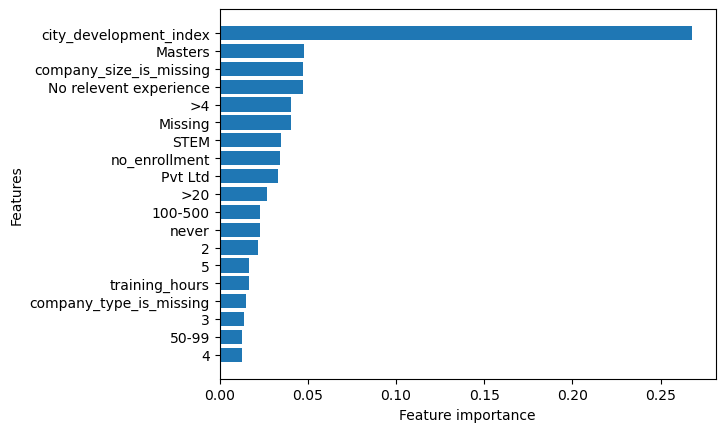

In [74]:
plot_features(X.columns, ideal_model.feature_importances_)

# Conclusion

This project analysed HR recruitment data to understand the factors influencing job change among data science candidates.

Key findings include:

- Early career candidates show a higher probability of job change.
- City development index influences job mobility.
- Company size and experience level are important predictors.

Machine learning models such as Random Forest and Gradient Boosting achieved strong predictive performance and successfully identified the key factors influencing candidate retention.

These insights can help HR teams develop more effective recruitment and retention strategies.